In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [8]:
games = 50
max_rounds = 30

rolls = np.random.randint(1, 7, size=(games, max_rounds, 2, 3))

sums = rolls.sum(axis=3)

is_111 = np.all(rolls == 1, axis=3)

In [11]:
sum_diff = sums[:, :, 0] - sums[:, :, 1]
pl1_score = 0.5 + 0.5 * np.sign(sum_diff)
pl2_score = 0.5 - 0.5 * np.sign(sum_diff)

any_111 = is_111[:, :, 0] | is_111[:, :, 1]

pl1_score[any_111] = is_111[:, :, 0][any_111].astype(float)
pl2_score[any_111] = is_111[:, :, 1][any_111].astype(float)

points = np.stack((pl1_score, pl2_score), axis=2)

In [23]:
cuml_points = np.cumsum(points, axis=1)

valid_win = (cuml_points[:, :, 0] >= 5) | (cuml_points[:, :, 1] >= 5)
not_tie = cuml_points[:, :, 0] != cuml_points[:, :, 1]
win_mask = valid_win & not_tie

win_rounds = np.argmax(win_mask, axis=1)

pl1_final = cuml_points[np.arange(games), win_rounds, 0]
pl2_final = cuml_points[np.arange(games), win_rounds, 1]

pl1_wins = np.sum(pl1_final > pl2_final)

print(f"Player 1 won {pl1_wins} out of {games} games.")
print(f"Probability of Player 1 winning: {pl1_wins / games:.2f}")


Player 1 won 25 out of 50 games.
Probability of Player 1 winning: 0.50


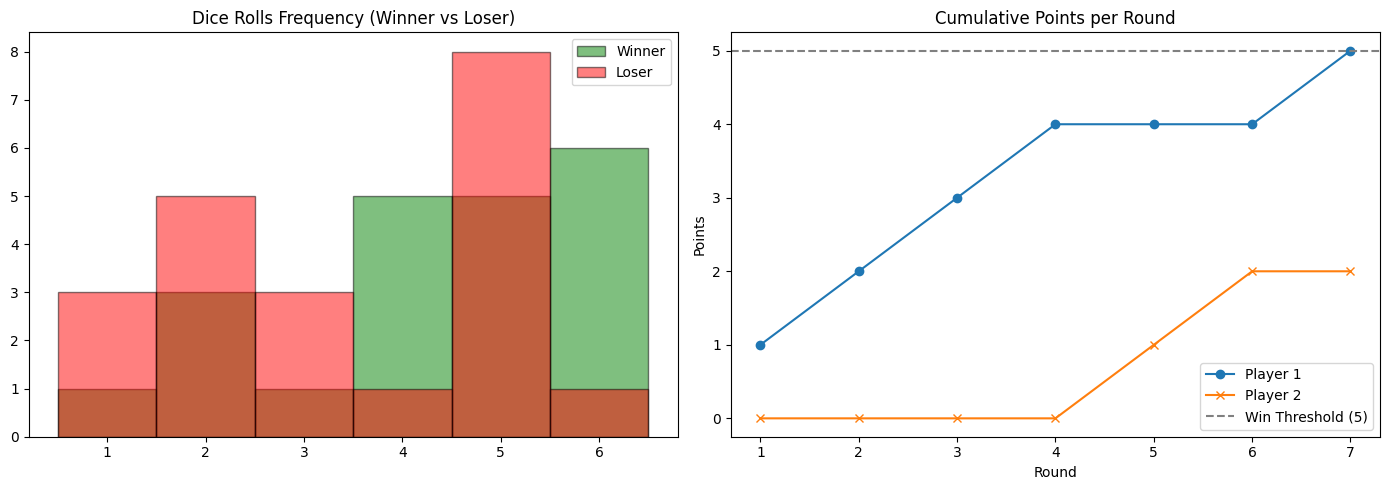

In [17]:
game_idx = 0
rounds_played = win_rounds[game_idx] + 1

game_rolls = rolls[game_idx, :rounds_played]
game_cum_pts = cuml_points[game_idx, :rounds_played]

winner_idx = 0 if pl1_final[game_idx] > pl2_final[game_idx] else 1
loser_idx = 1 - winner_idx

winner_rolls = game_rolls[:, winner_idx, :].flatten()
loser_rolls = game_rolls[:, loser_idx, :].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(winner_rolls, bins=np.arange(1, 8)-0.5, alpha=0.5, label='Winner', color='green', edgecolor='black')
axes[0].hist(loser_rolls, bins=np.arange(1, 8)-0.5, alpha=0.5, label='Loser', color='red', edgecolor='black')
axes[0].set_title('Dice Rolls Frequency (Winner vs Loser)')
axes[0].set_xticks(range(1, 7))
axes[0].legend()

# Line chart
axes[1].plot(range(1, rounds_played + 1), game_cum_pts[:, 0], marker='o', label='Player 1')
axes[1].plot(range(1, rounds_played + 1), game_cum_pts[:, 1], marker='x', label='Player 2')
axes[1].axhline(y=5, color='gray', linestyle='--', label='Win Threshold (5)')
axes[1].set_title('Cumulative Points per Round')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Points')
axes[1].legend()

plt.tight_layout()
plt.show()


In [21]:
all_individual_rolls = rolls.flatten()
all_sums = sums.flatten()

observed_freq, _ = np.histogram(all_individual_rolls, bins=np.arange(1, 8))
expected_freq = np.full(6, len(all_individual_rolls) / 6)
chi_stat, chi_p = stats.chisquare(f_obs=observed_freq, f_exp=expected_freq)

print("Individual Rolls ")
print(f"Chi-Square p-value: {chi_p:.4f}")

sample_sums = np.random.choice(all_sums, 1000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(sample_sums)

print("\nSum of 3 Dice ")
print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}")


Individual Rolls 
Chi-Square p-value: 0.6380

Sum of 3 Dice 
Shapiro-Wilk p-value: 0.0000
